
#### Teoría de Circuitos II - UTN.BA

# Tarea Semanal 2
#### Rodríguez Silvosa, Martín

### Consigna
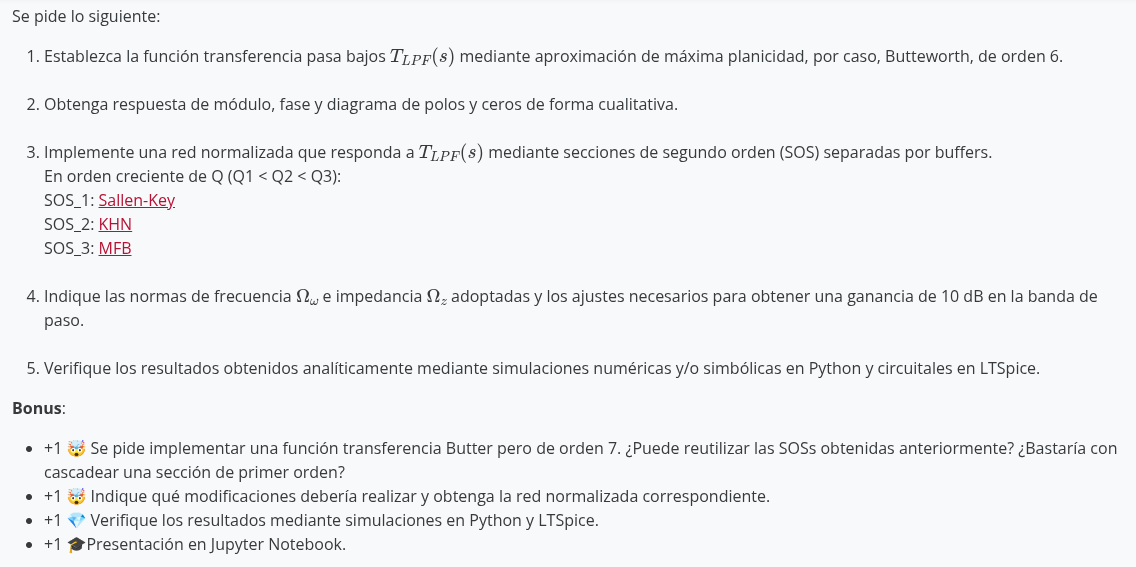

### Transferencia pasabajos mediante aproximación de máxima planicidad Butterworth:

$$
|T_{LPF}(s)|^2 = \left.{\frac{1}{1+{\omega}^{2n}}}\right|_{\omega = \frac{s}{j}} = \frac{1}{1+(-1)^n \cdot s^{2n}} = T(s) \cdot T(-s)
$$

#### Reemplazamos $n=6$:

$$
|T_{LPF}(s)|^2 = \frac{1}{1+(-1)^6 \cdot s^{12}} = \frac{1}{1+s^{12}} = T(s) \cdot T(-s) = {\frac{1}{s^6+a\cdot s^5+b\cdot s^4 + c\cdot s^3+d\cdot s^2 +e\cdot s+1}}\cdot{\frac{1}{s^6-a\cdot s^5+b\cdot s^4 - c\cdot s^3+d\cdot s^2 -e\cdot s+1}}
$$

#### El planteo nos queda muy complejo y tendríamos demasiadas variables en juego que ajustar, pero podemos simplificar el análisis como 3 orden 2 en cascada, considerando cada sección independiente separadas con buffers:

$$
T(s) \cdot T(-s) = {\frac{1}{s^2+a_1 \cdot s + 1}} \cdot {\frac{1}{s^2+a_2 \cdot s + 1}} \cdot {\frac{1}{s^2+a_3 \cdot s + 1}} \cdot {\frac{1}{s^2-a_1 \cdot s + 1}} \cdot {\frac{1}{s^2-a_2 \cdot s + 1}} \cdot {\frac{1}{s^2-a_3 \cdot s + 1}}
$$

#### En particular nos quedará que cada sección $S$ estará dada por:
$$
T_{Sn}(s) = \frac{1}{s^2+\frac{1}{Q_{Sn}}\cdot s+1}
$$
#### Donde al tener un orden 6 par, Q quedará como:
$$
Q_{Sn} = \frac{1}{2\cdot cos({\frac{\pi}{2 \cdot 6}}+{\frac{k\cdot \pi}{6}})}
$$
$$
\left. Q_{S1}\right|_{k=0} = \frac{1}{2\cdot cos({\frac{\pi}{12}})} = \frac{\sqrt{6} - \sqrt{2}}{2} \approx 0,5176
$$
$$
\left. Q_{S2}\right|_{k=1} = \frac{1}{2\cdot cos({\frac{\pi}{4}})} = \frac{\sqrt{2} }{2} \approx 0,707
$$
$$
\left. Q_{S3}\right|_{k=2} = \frac{1}{2\cdot cos({\frac{5\pi}{12}})} = \frac{\sqrt{6} + \sqrt{2}}{2} \approx 1,932
$$

#### Importación de librerías a usar:

In [1]:
import sympy as sp
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

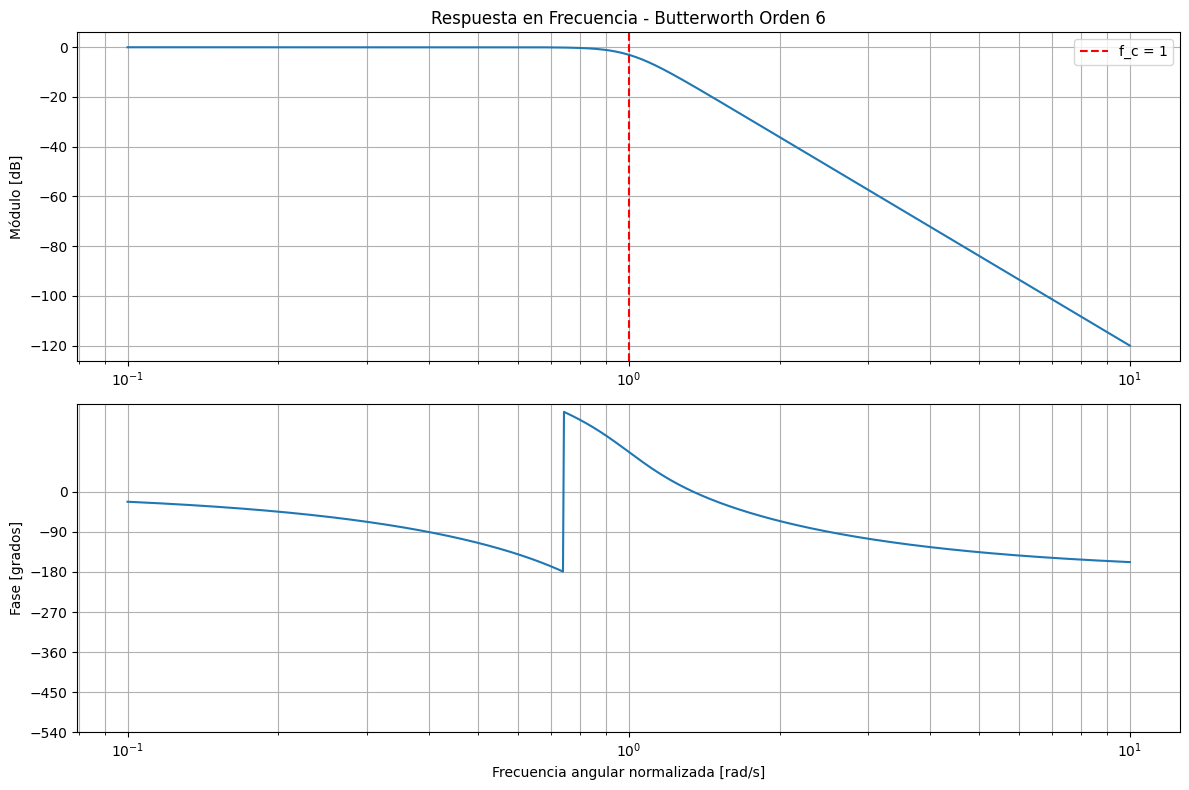

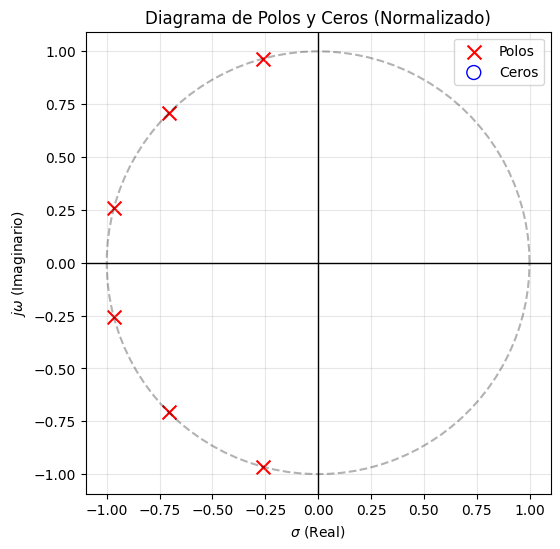

In [8]:

# 1. Definición del filtro Butterworth de orden 6
n = 6
fs = 1000  # Frecuencia de muestreo
low_pass = signal.butter(n, 1, btype='low', analog=True, output='sos')
# También obtenemos ceros, polos y ganancia (zpk) para el diagrama
z, p, k = signal.butter(n, 1, btype='low', analog=True, output='zpk')

# 2. Respuesta en frecuencia (Módulo y Fase)
w, h = signal.freqs_zpk(z, p, k, worN=np.logspace(-1, 1, 1000))

# Creamos la figura
plt.figure(figsize=(12, 8))

# Subplot Módulo
plt.subplot(2, 1, 1)
plt.semilogx(w, 20 * np.log10(np.abs(h)))
plt.title('Respuesta en Frecuencia - Butterworth Orden 6')
plt.ylabel('Módulo [dB]')
plt.grid(True, which="both", ls="-")
plt.axvline(1, color='red', linestyle='--', label='f_c = 1')
plt.legend()

# Subplot Fase
plt.subplot(2, 1, 2)
plt.semilogx(w, np.angle(h, deg=True))
plt.ylabel('Fase [grados]')
plt.xlabel('Frecuencia angular normalizada [rad/s]')
plt.yticks([-90*i for i in range(7)]) # Marcas cada 90 grados
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

# 3. Diagrama de Polos y Ceros
plt.figure(figsize=(6, 6))
# Dibujamos círculo unitario
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)

# Graficamos Polos y Ceros
plt.scatter(np.real(p), np.imag(p), s=100, marker='x', color='red', label='Polos')
plt.scatter(np.real(z), np.imag(z), s=100, marker='o', facecolors='none', edgecolors='blue', label='Ceros')

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title('Diagrama de Polos y Ceros (Normalizado)')
plt.xlabel('$\sigma$ (Real)')
plt.ylabel('$j\omega$ (Imaginario)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

### Simulación LTSpice:

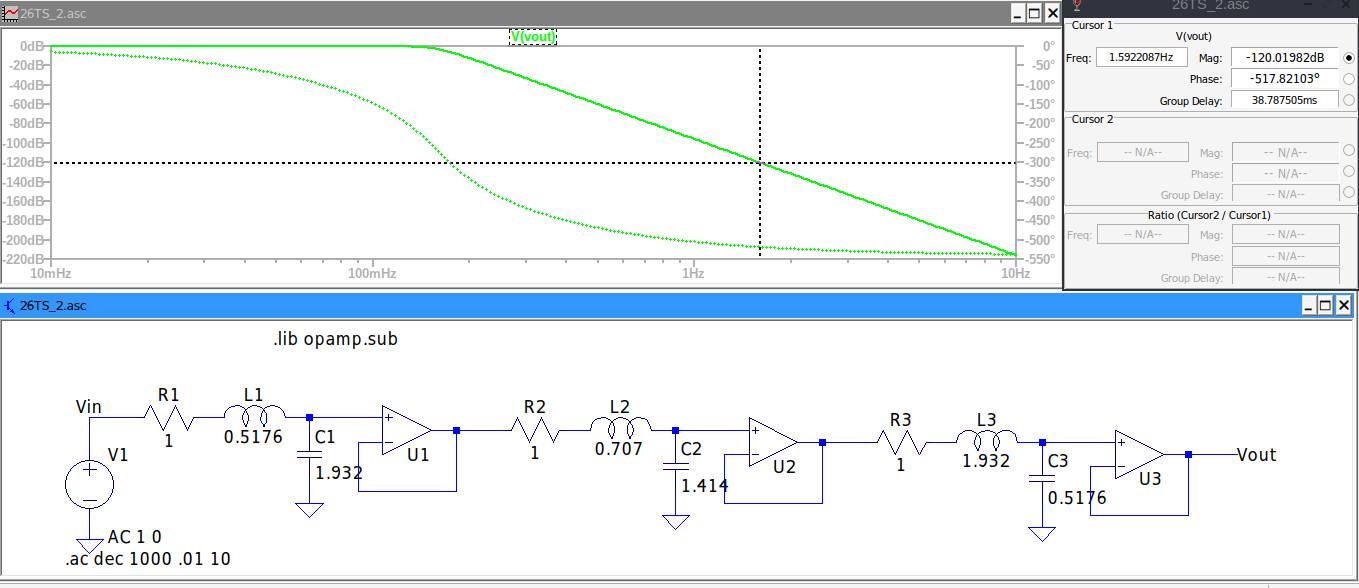

#### LA simulación básica pasiva en LTSpice con los Q hallados verifican el análisis.
### Bastaría con convertir el buffer final en un no inversor para conseguir la ganancia de 10dB

### Filtro orden 7:
#### Se podría usar la misma topología y agregar 1 etapa más de 1er orden que agregue el polo real para obtener el filtro de orden 7, pudiendo usar lo ya implementado pero el espacio angular entre los polos tendría que disminuir porque tienen que mantenerse equispaciados.

### Análisis nodal circuito Sallen-Key pasabajos:
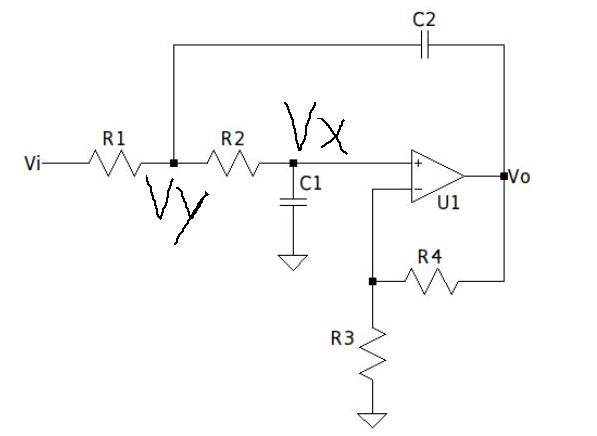
#### Asumo operacional realimentado V(-) = V(+)
#### Nodo Vy:
$$
Vy \cdot (G1+G2+SC2)-Vi \cdot G1-Vx \cdot G2-Vo \cdot SC2 = 0
$$
#### Nodo Vx V(-):
$$
Vx \cdot (G4+G3) - Vo \cdot G4 = 0
$$
#### Nodo Vx V(+):
$$
(Vy-Vx) \cdot G2 - Vx \cdot SC1 = 0
$$
#### Resolviendo nos queda:
$$
\frac{Vo}{Vi} = T_{(S)}= \frac{G3+G4}{G4} \cdot \frac{\frac{G1G2}{C1C2}}{S^2+S \cdot \left( \frac{G1}{C2} + \frac{G2}{C2}- \frac{G2G3}{C1G4} \right) + \frac{G1G2}{C1C2}}
$$
#### Donde:
$$
{\omega_0}^2 = \frac{G1G2}{C1C2}
$$
$$
\frac{\omega_0}{Q} = \frac{G1}{C2} + \frac{G2}{C2}- \frac{G2G3}{C1G4}
$$
$$
K = \frac{G3+G4}{G4}
$$
#### Normalizando nomenclatura nos queda:
$$
T_{(S)} = K \cdot \frac{{\omega_0}^2}{S^2+S \cdot \frac{\omega_0}{Q} + {\omega_0}^2}
$$

### Verificación de la transferencia con SymPy:

In [4]:
# Parámetros:
Y1, Y2, Y3, Y4, Y5, Y6 = sp.symbols("Y1, Y2, Y3, Y4, Y5, Y6")
V1, V2, V3, V4 = sp.symbols("V1, V2, V3, V4")
G1, G2, G3, G4, C1, C2, wt, w0 = sp.symbols("G1, G2, G3, G4, C1, C2, wt, w0", real=True, positive=True) 
s = sp.symbols('s')

eq1 = V3*(Y1+Y2+Y6) - V1*Y1 - V2*Y6 - V4*Y2
eq2 = V4*(Y4+Y3) - V2*Y4
eq3 = V4*(Y5+Y2) - V3*Y2

# 1: Resolver los nodos internos V3 y V4 en función de V1 y V2
solucion = sp.solve([eq1, eq2, eq3], [V2, V3, V4], dict=True)

# Extraemos la solución del primer (y único) diccionario de la lista
# Buscamos V2, que estará expresado en función de V1
V2_resuelto = solucion[0][V2]

# Calculamos la transferencia T = V2 / V1
T = sp.simplify(V2_resuelto / V1)

# Impresión en formato original (Admitancias)
print_latex(a_equal_b_latex_s('T(s)', T))

# Sustitución de componentes analógicos
T_s = T.subs({
    Y1: G1,
    Y2: G2,
    Y3: G3,
    Y4: G4,
    Y5: s*C1,
    Y6: s*C2
})

# Tus bloques de simplificación originales
T_s = sp.together(T_s)
T_s = sp.factor(T_s)
T_s = sp.simplify(T_s)

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### La verificación simbólica se verifica al sacar G4 factor común en el denominador y juntarlo con el término G3+G4 del nominador para K, y luego sacar factor común C1C2 y subirlo al nominador para $\omega_0^2$

### Análisis nodal circuito Variable de estado Tow-Thomas Kerwin-Huelsman-Newcomb (KHN)

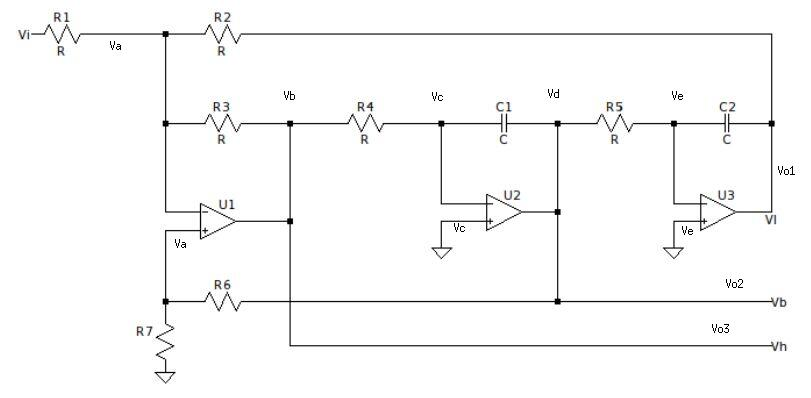

#### Asumo operacionales realimentados V(-) = V(+) y analizo aquellos nodos que no tienen una salida de un operacional:
$$
Menciono \ que \ Vd = Vo2 \ ; \ Vb = Vo3
$$
#### Nodo Va V(-):
$$
Va \cdot (G1+G2+G3)- Vi \cdot G1 - Vo1 \cdot G2 - Vb \cdot G3 = 0
$$
#### Nodo Va V(+):
$$
Va \cdot (G6+G7) - Vd \cdot G6 = 0 \rightarrow Va = Vd \cdot \frac{G6}{G6+G7}
$$
#### Nodo Vc V(-):
$$
Vc \cdot (G4+SC1) - Vb \cdot G4 - Vd \cdot SC1 = 0
$$
#### Nodo Vc V(+):
$$
Vc = 0 \rightarrow - Vb \cdot G4 = Vd \cdot SC1 \rightarrow -Vb = Vd \cdot \frac{SC1}{G4}
$$
#### Nodo Ve V(-):
$$
Ve \cdot (G5+SC2) - Vd \cdot G5 - Vo1 \cdot SC2 = 0
$$
#### Nodo Ve V(+):
$$
Ve = 0 \rightarrow - Vd \cdot G5 = Vo1 \cdot SC2 \rightarrow -Vd = Vo1 \cdot \frac{SC2}{G5}
$$
#### Resolviendo nos queda:
#### Nodo Va V(-) reemplazando:
$$
-Vo1 \cdot \frac{SC2}{G5} \cdot \frac{G6}{G6+G7} \cdot (G1+G2+G3)- Vi \cdot G1 - Vo1 \cdot G2 - Vo1 \cdot \frac{SC2}{G5} \cdot \frac{SC1}{G4} \cdot G3 = 0
$$

$$
-Vi \cdot G1 = Vo1 \cdot \left( \frac{SC2}{G5} \cdot \frac{G6}{G6+G7} \cdot (G1+G2+G3) + G2 + \frac{SC2}{G5} \cdot \frac{SC1}{G4} \cdot G3 \right)
$$

$$
\frac{Vo1}{Vi} = T_{(S)}= - \frac{G1G5G4 \cdot (G6+G7)}{SC2 \cdot G6G4 \cdot (G1+G2+G3) + G2G5G4 \cdot (G6+G7) + SC2 \cdot SC1 \cdot G3 \cdot (G6+G7)}
$$
#### Dejando $S^2$ mónico:
$$
\frac{Vo1}{Vi} = T_{(S)}= - \frac{1}{C2C1G3 \cdot (G6+G7)} \cdot \frac{G1G5G4 \cdot (G6+G7)}{S \cdot \frac{G6G4 \cdot (G1+G2+G3)}{C1G3 \cdot (G6+G7)} + \frac{G2G5G4}{C2C1G3} + S^2}
$$
#### Simplificando:
$$
\frac{Vo1}{Vi} = T_{(S)}= - \frac{\frac{G1G5G4}{C2C1G3}}{S^2 + S \cdot \frac{G6G4 \cdot (G1+G2+G3)}{C1G3 \cdot (G6+G7)} + \frac{G2G5G4}{C2C1G3}}
$$
#### Donde:
$$
{\omega_0}^2 = \frac{G1G5G4}{C2C1G3}
$$
$$
\frac{\omega_0}{Q} = \frac{G6G4 \cdot (G1+G2+G3)}{C1G3 \cdot (G6+G7)}
$$
$$
K = -1 \ (desfase)
$$
#### Normalizando nomenclatura nos queda:
$$
T_{(S)} = K \cdot \frac{{\omega_0}^2}{S^2+S \cdot \frac{\omega_0}{Q} + {\omega_0}^2}
$$

### Verificación de la transferencia con SymPy:

In [11]:
# Parámetros:
Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9 = sp.symbols("Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9")
Vi, Vo1, Va, Vb, Vc, Vd, Ve = sp.symbols("Vi, Vo1, Va, Vb, Vc, Vd, Ve")
G1, G2, G3, G4, G5, G6, G7, C1, C2, wt, w0 = sp.symbols("G1, G2, G3, G4, G5, G6, G7, C1, C2, wt, w0", real=True, positive=True) 
s = sp.symbols('s')

eq1 = Va*(Y1+Y2+Y3) - Vi*Y1 - Vo1*Y2 - Vb*Y3
eq2 = Va*(Y6+Y7) - Vd*Y6
eq3 = Vc*(Y4+Y8) - Vb*Y4 - Vd*Y8
eq4 = Vc*1
eq5 = Ve*(Y5+Y9) - Vd*Y5 - Vo1*Y9
eq6 = Ve*1

# 1: Resolver
solucion = sp.solve([eq1, eq2, eq3, eq4, eq5, eq6], [Vo1, Va, Vb, Vc, Vd, Ve], dict=True)

# Extraemos la solución del primer (y único) diccionario de la lista
# Buscamos Vo1, que estará expresado en función de Vi
Vo1_resuelto = solucion[0][Vo1]

# Calculamos la transferencia T = Vo1 / Vi
T = sp.simplify(Vo1_resuelto / Vi)

# Impresión en formato original (Admitancias)
print_latex(a_equal_b_latex_s('T(s)', T))

# Sustitución de componentes analógicos
T_s = T.subs({
    Y1: G1,
    Y2: G2,
    Y3: G3,
    Y4: G4,
    Y5: G5,
    Y6: G6,
    Y7: G7,
    Y8: s*C1,
    Y9: s*C2
})

# Tus bloques de simplificación originales
T_s = sp.together(T_s)
T_s = sp.factor(T_s)
T_s = sp.simplify(T_s)

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

# Factor divisor para simplificar una vez viendo la transferencia resultante:
divisor = C1*C2*G3*G6 + C1*C2*G3*G7

# sp.fraction separa cualquier expresión en una tupla (numerador, denominador)
num, den = sp.fraction(T_s)

# Dividimos cada parte por el factor y expandimos
num_dividido = sp.expand(num / divisor)
den_dividido = sp.collect(sp.expand(den / divisor), s, evaluate=sp.simplify)

# Reconstruimos la transferencia
T_s = num_dividido / den_dividido

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

T_s = sp.simplify(T_s)

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

# Factor divisor para simplificar una vez viendo la transferencia resultante:
divisor = C1*C2*G3*(G6+G7)

# sp.fraction separa cualquier expresión en una tupla (numerador, denominador)
num, den = sp.fraction(T_s)

# Dividimos cada parte por el factor y expandimos
num_dividido = sp.expand(num / divisor)
den_dividido = sp.collect(den / divisor, s)

# Reconstruimos la transferencia
T_s = num_dividido / den_dividido

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

T_s = sp.simplify(T_s)

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Seguimos simplificando la expresión por fuera de simulación:
#### Sacando factor común del denominador $C1C2G3 \cdot (G6+G7)$:
$$
T(s)= - \frac{G6+G7}{G6+G7} \cdot \frac{ \frac{G1G4G5}{C1C2G3} }{s^2 + s \cdot \frac{C2G4G6 \cdot (G1+G2+G3)}{C1C2G3 \cdot (G6+G7)} + \frac{G2G4G5 \cdot (G6+G7)}{C1C2G3 \cdot (G6+G7)}}
$$

#### Simplificando nos queda:
$$
T(s)= -\frac{ \frac{G1G4G5}{C1C2G3} }{s^2 + s \cdot \frac{G6}{G6+G7} \cdot \frac{C2G4 \cdot (G1+G2+G3)}{C1C2G3} + \frac{G2G4G5}{C1C2G3}}
$$

#### La simulación verifica la transferencia pasabajos del KHN

### Análisis nodal circuito Multiple Feedback MFB configuración pasabajos:

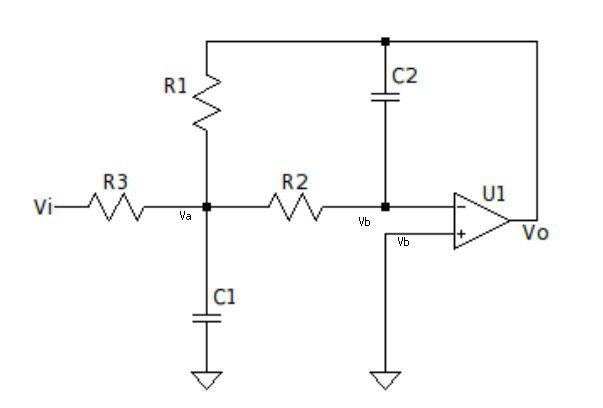

#### Asumo operacional realimentado V(-) = V(+) y analizo aquellos nodos que no tienen una salida de un operacional:
#### Nodo Va:
$$
Va \cdot (G1+G2+G3+SC1)- Vi \cdot G3 - Vo \cdot G1 - Vb \cdot G2 = 0
$$
#### Nodo Vb V(-):
$$
Vb \cdot (G2+SC2) - Va \cdot G2 - Vo \cdot SC2 = 0
$$
#### Nodo Vb V(+):
$$
Vb = 0 \rightarrow - Va \cdot G2 - Vo \cdot SC2 = 0 \rightarrow Va = -Vo \cdot \frac{SC2}{G2}
$$
#### Resolviendo nos queda:
#### Nodo Va reemplazando:
$$
-Vo \cdot \frac{SC2}{G2} \cdot (G1+G2+G3+SC1) - Vi \cdot G3 - Vo \cdot G1 = 0
$$

$$
-Vi \cdot G3 = Vo \cdot \left( G1 + \frac{SC2}{G2} \cdot (G1+G2+G3+SC1) \right)
$$

$$
\frac{Vo}{Vi} = T_{(S)}= - \frac{G3G2}{G1G2 + SC2 \cdot (G1+G2+G3) + S^2 C2C1}
$$
#### Dejando $S^2$ mónico:
$$
\frac{Vo}{Vi} = T_{(S)}= - \frac{1}{C2C1} \cdot \frac{G3G2}{\frac{G1G2}{C2C1} + S \cdot \frac{G1+G2+G3}{C1} + S^2}
$$
#### Simplificando:
$$
\frac{Vo}{Vi} = T_{(S)}= - \frac{\frac{G3G2}{C2C1}}{S^2 + S \cdot \frac{G1+G2+G3}{C1} + \frac{G1G2}{C2C1}}
$$
#### Donde:
$$
{\omega_0}^2 = \frac{G1G2}{C2C1} = \frac{G3G2}{C2C1} \rightarrow G1=G3 \ condición \ obligatoria
$$
$$
\frac{\omega_0}{Q} = \frac{G1+G2+G3}{C1}
$$
$$
K = -1 \ (desfase)
$$
#### Normalizando nomenclatura nos queda:
$$
T_{(S)} = K \cdot \frac{{\omega_0}^2}{S^2+S \cdot \frac{\omega_0}{Q} + {\omega_0}^2}
$$

### Verificación de la transferencia con SymPy:

In [14]:
# Parámetros:
Y1, Y2, Y3, Y4, Y5 = sp.symbols("Y1, Y2, Y3, Y4, Y5")
Vi, Vo, Va, Vb = sp.symbols("Vi, Vo, Va, Vb")
G1, G2, G3, C1, C2, wt, w0 = sp.symbols("G1, G2, G3, C1, C2, wt, w0", real = True, posistive = True) 
s = sp.symbols('S')

# Consideramos V1 = Vi, V2 = Vo, V3 = VR1, V4 = V- operacional
aa = sp.solve([ 
                Va*(Y1+Y2+Y3+Y4) - Vi*Y3 - Vo*Y1 - Vb*Y2, 
                Vb*(Y2+Y5) - Va*Y2 - Vo*Y5,
                Vb*1
                ], 
                [Vo, Va, Vb])
T = sp.simplify(aa[Vo]/Vi)
print_latex(a_equal_b_latex_s('T(S)', T))

T_s = T.subs({
    Y1: G1,
    Y2: G2,
    Y3: G3,
    Y4: s*C1,
    Y5: s*C2
})
print_latex(a_equal_b_latex_s('T(S)', T_s))
T_s = sp.together(T_s)
T_s = sp.factor(T_s)
T_s = sp.simplify(T_s)
print_latex(a_equal_b_latex_s('T(S)', T_s))

# Factor divisor para simplificar una vez viendo la transferencia resultante:
divisor = C1*C2

# sp.fraction separa cualquier expresión en una tupla (numerador, denominador)
num, den = sp.fraction(T_s)

# Dividimos cada parte por el factor y expandimos
num_dividido = sp.expand(num / divisor)
den_dividido = sp.collect(sp.expand(den / divisor), s, evaluate=sp.simplify)

# Reconstruimos la transferencia
T_s = num_dividido / den_dividido

# Impresión del resultado final con componentes
print_latex(a_equal_b_latex_s('T(s)', T_s))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Simplificando la expresión simulada nos queda:
$$
T(s) = - \frac{ \frac{G2G3}{C1C2} }{s^2 + s \cdot \frac{G1+G2+G3}{C1} + \frac{G1G2}{C1C2}}
$$

#### La simulación verifica la transferencia

### Momento de normalizar para síntesis y simulación:

#### Elegiremos orden creciente de Q: KHN, MFB, Sallen-key para fijar la ganancia al final de los 10dB

### KHN:
$$
Normalizo \ \omega_0 = 1, \ Q = \frac{\sqrt{6}-\sqrt{2}}{2}
$$
#### Parámetros:
$$
{\omega_0}^2 = \frac{G1G5G4}{C2C1G3} = 1 \rightarrow C2C1G3 = G1G5G4
$$

$$
\frac{1}{Q} = \frac{G6G4 \cdot (G1+G2+G3)}{C1G3 \cdot (G6+G7)} \rightarrow \frac{C1G3 \cdot (G6+G7)}{G6G4 \cdot (G1+G2+G3)} = \frac{\sqrt{6}-\sqrt{2}}{2} \approx 0.5176
$$

#### Elijo $C1=C2=G3=G1=G5=G4=1$:
$$
\frac{\sqrt{6}-\sqrt{2}}{2} = \frac{G6+G7}{G6 \cdot (2 + G2)}
$$

#### Elijo $G6=G2=1$:
$$
\frac{\sqrt{6}-\sqrt{2}}{2} = \frac{1+G7}{3} \rightarrow G7 = \frac{3\cdot \sqrt{6} - 3 \cdot \sqrt{2} - 2}{2} \approx 0.5529
$$

### MFB:
$$
Normalizo \ \omega_0 = 1, \ Q = \frac{\sqrt{2}}{2} \approx 0.707
$$
#### Parámetros:
$$
{\omega_0}^2 = \frac{G1G2}{C2C1} = \frac{G3G2}{C2C1} \rightarrow G1=G3 \ condición \ obligatoria
$$

$$
{\omega_0}^2 = \frac{G1G2}{C2C1} = 1 \rightarrow C2C1 = G1G2 \ con \ G3=G1
$$

$$
\frac{1}{Q} = \frac{G1+G2+G3}{C1} \rightarrow Q = \frac{C1}{G1+G2+G3} = \frac{C1}{2\cdot G1 + G2} = \frac{\sqrt{2}}{2}
$$

#### Elijo $C1 = 2\sqrt{2}$ y $G1=G3=1$:
$$
\frac{\sqrt{2}}{2} = \frac{2 \cdot \sqrt{2}}{2+G2} \rightarrow \frac{\sqrt{2}}{1+\frac{G2}{2}} = \frac{\sqrt{2}}{2} \rightarrow G2 = 2
$$

$$
C2 \cdot 2\sqrt{2} = 1 \cdot 2 \rightarrow C2 = \frac{1}{\sqrt{2}} \approx 0.707
$$

$$
C1 = 2\sqrt{2} \approx 2.8284
$$

### Sallen-key:
$$
Normalizo \ \omega_0 = 1, \ Q = \frac{\sqrt{6} + \sqrt{2}}{2} \approx 1.932
$$
#### Parámetros:
$$
{\omega_0}^2 = \frac{G1G2}{C1C2} = 1 \rightarrow C1C2 = G1G2
$$

$$
\frac{1}{Q} = \frac{G1}{C2} + \frac{G2}{C2}- \frac{G2G3}{C1G4}
$$

$$
K = \frac{G3+G4}{G4}
$$
#### Primero sintetizamos para ganancia 1 (0dB):
$$
G3 = 0
$$

$$
\frac{1}{Q} = \frac{G1C1G4 + G2C1G4 - G2G3C2 }{C2C1G4} \rightarrow \frac{C2C1G4}{G1C1G4 + G2C1G4 - G2G3C2} = Q = \frac{\sqrt{6} + \sqrt{2}}{2} \approx 1.932
$$


#### Con $G3=0$:
$$
\frac{C2C1G4}{C1G4(G1+G2)} = Q \rightarrow \frac{C2}{G1+G2} = \frac{\sqrt{6}+\sqrt{2}}{2}
$$

#### Elijo $G1=G2=G4=1$:
$$
C2 = \sqrt{6}+\sqrt{2} \rightarrow C1 = \frac{1}{\sqrt{6}+\sqrt{2}}
$$

### Simulación LTSpice:

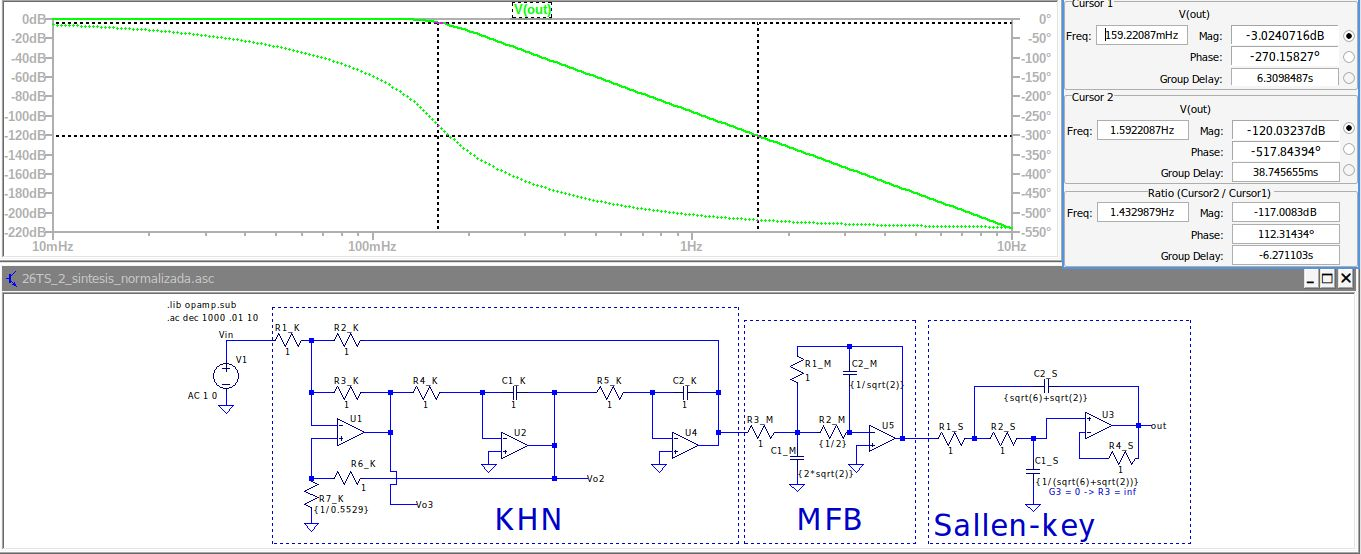

### Ajuste para ganancia de 10dB en banda de paso:
#### Simplemente ajustaremos la ganancia del Sallen-key:
$$
K = \frac{G3+G4}{G4}
$$
$$
Ganancia \ 10dB \rightarrow \ 10dB = 20 \cdot log(K) \rightarrow K = 10^{\frac{10dB}{20}} \rightarrow K = \sqrt{10} \approx 3.1622
$$

$$
\sqrt{10} = \frac{G3+G4}{G4} \rightarrow \frac{G3}{G4} + 1 \approx 3.1622 \rightarrow \frac{G3}{G4} \approx 2.1622
$$

$$
\frac{C2C1G4}{G1C1G4 + G2C1G4 - G2G3C2} = Q = \frac{\sqrt{6} + \sqrt{2}}{2} \approx 1.932
$$

$$
\frac{C2C1}{\frac{1}{G4} \cdot (G1C1G4 + G2C1G4 - G2G3C2)} = \frac{C2C1}{G1C1 + G2C1 - G2C2 \cdot \frac{G3}{G4}}
$$

$$
Q = \frac{\sqrt{6} + \sqrt{2}}{2} = \frac{C2C1}{C1(G1+G2) - G2C2 \cdot 2.1622}
$$

#### Elijo restricciones:
$$
C2 = 1:
$$

$$
1.932 = \frac{C1}{C1(G1+G2) - G2 \cdot 2.1622}
$$
#### Elijo $G1=1$ :
$$
Entonces \ C1 = G2
$$
#### Reemplazando:
$$
1.932 = \frac{G2}{G2 (1+G2) - G2 \cdot 2.1622}
$$

#### Se puede verificar que:
$$
C1 = G2 = 1.679798
$$
#### Falta determinar $G3$ y $G4$:
$$
\frac{G3}{G4} = 2.1622 \rightarrow G4 = 1 \ y \ G3 = 2.1622
$$

### Simulación con ganancia:
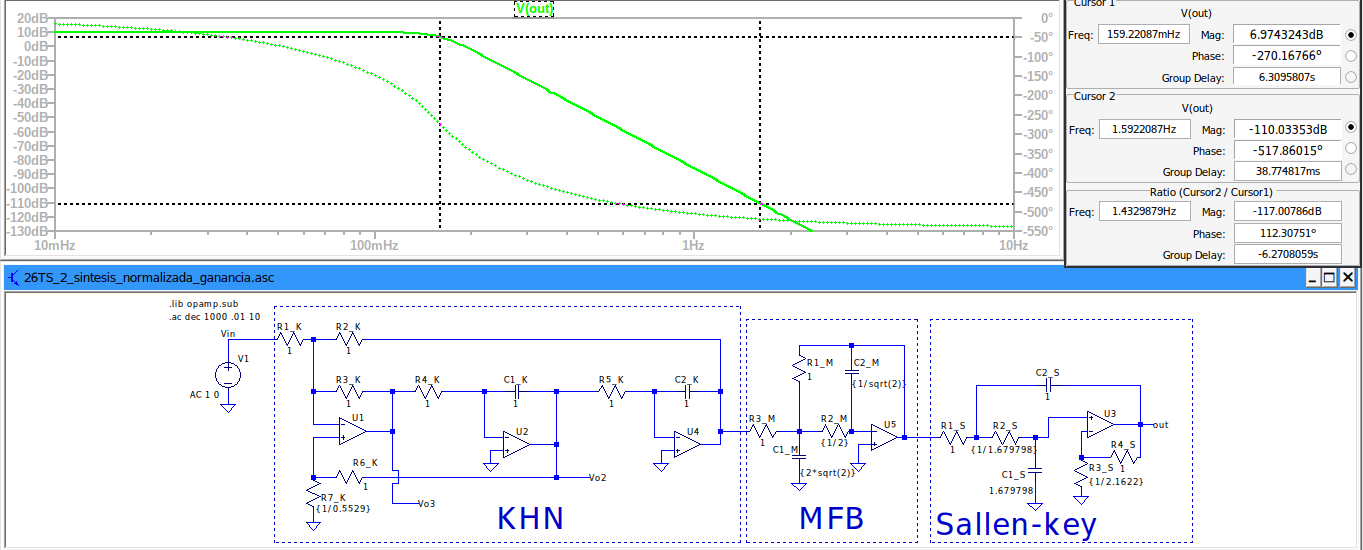

### Implemento una desnormalización arbitraria:

#### Defino:
$$
f_0 = 10KHz \rightarrow \omega_0 = 62831.85307 \frac{rad}{seg}
$$
$$
\Omega_{\omega} = 62831.85307 \frac{rad}{seg}
$$
$$
\Omega_z = 10K\Omega
$$

#### KHN:
$$
R1=R2=R3=R4=R5=R6 = R1_N \cdot \Omega_z = 10K\Omega
$$
$$
R7 = R7_N \cdot \Omega_z = \frac{1}{0.5529} \cdot 10K\Omega = 18086 \Omega
$$
$$
C1=C2 = \frac{C1_N}{\Omega_z \cdot \Omega_{\omega}} = \frac{1}{10000 \cdot 62831.85307} = 1.59155 nF
$$

#### MFB:
$$
R1=R3 = R1_N \cdot \Omega_z = 10K\Omega
$$
$$
R2 = R2_N \cdot \Omega_z = \frac{1}{2} \cdot 10K\Omega = 5000 \Omega
$$
$$
C1 = \frac{C1_N}{\Omega_z \cdot \Omega_{\omega}} = \frac{2\sqrt{2}}{10000 \cdot 62831.85307} = 4.50158 nF
$$
$$
C2 = \frac{C2_N}{\Omega_z \cdot \Omega_{\omega}} = \frac{\frac{1}{\sqrt{2}}}{10000 \cdot 62831.85307} = 1.1254 nF
$$

#### Sallen-key:
$$
R1=R4 = R1_N \cdot \Omega_z = 10K\Omega
$$
$$
R2 = R2_N \cdot \Omega_z = \frac{1}{1.679798} \cdot 10K\Omega = 5953 \Omega
$$
$$
R3 = R3_N \cdot \Omega_z = \frac{1}{2.1622} \cdot 10K\Omega = 4625 \Omega
$$
$$
C1 = \frac{C1_N}{\Omega_z \cdot \Omega_{\omega}} = \frac{1.679798}{10000 \cdot 62831.85307} = 2.67348 nF
$$
$$
C2 = \frac{C2_N}{\Omega_z \cdot \Omega_{\omega}} = \frac{1}{10000 \cdot 62831.85307} = 1.59155 nF
$$

### Simulación desnormalizada:
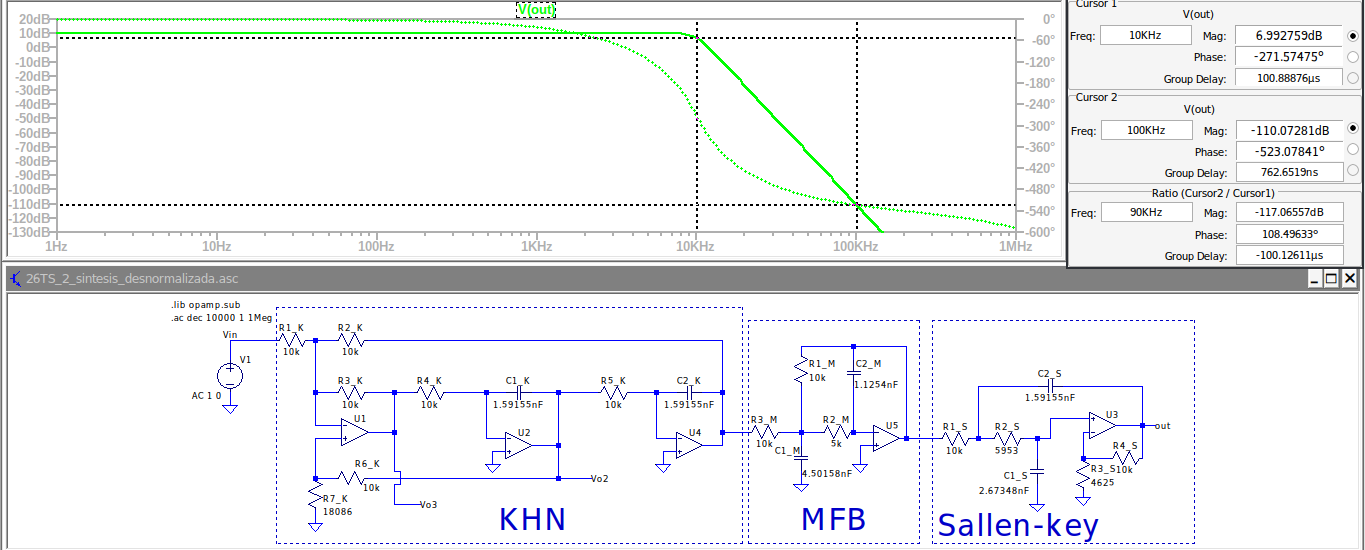

### El filtro cumple con el diseño esperado